In [1]:
import glob
import json
import pandas as pd

MERGES = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/scaled_w_merge'
NO_MERGES = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/scaled_no_merge_cap'
POST_MERGES = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/post_merge_resolution_merges'
POST_MERGES_NO_MERGES = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/post_merge_resolution_no_merge'

In [2]:
ds_summary = pd.read_csv('/home/ddon0001/PhD/experiments/scaled/pre-thesis/scaled_w_merge/summary.csv')
col_order = ds_summary.sort_values(by='total_det', ascending=False)['ds_name']

In [3]:
method_to_pth = {
    'merges': MERGES,
    'no_merges': NO_MERGES,
    'post_merges': POST_MERGES,
    'post_no_merges': POST_MERGES_NO_MERGES
}

In [4]:
method_metrics = {}
for method, pth in method_to_pth.items():
    all_metrics_jsons = glob.glob(pth + '/**/traccuracy-results.json', recursive=True)
    rows = []
    for json_file in all_metrics_jsons:
        ds_name = json_file.split('/')[-3]
        with open(json_file, 'r') as f:
            results = json.load(f)['traccuracy'][0]['results']
            rows.append({"ds_name": ds_name, **results})
    method_metrics[method] = pd.DataFrame(rows)

In [5]:
ds_names_w_resolved_merges = method_metrics['post_merges']['ds_name'].tolist()

In [14]:
cols_of_interest = [
    'ds_name',
    'False Positive Edges',
    'False Negative Edges',
]
err_cols = cols_of_interest[1:]

def get_summary_df(df):
    summary_df = df[df['ds_name'].isin(ds_names_w_resolved_merges)][cols_of_interest]
    summary_df['total_errors'] = summary_df[err_cols[0]] + summary_df[err_cols[1]]
    return summary_df

In [7]:
no_merges = method_metrics['no_merges']
no_merges_err_summary = get_summary_df(no_merges)
no_merges_err_summary

,ds_name,False Positive Edges,False Negative Edges,total_errors
5,PhC-C2DL-PSC_02,270,281,551
6,BF-C2DL-MuSC_02,114,206,320
7,BF-C2DL-HSC_01,9,10,19
9,Fluo-N3DH-CE_01,230,285,515
11,BF-C2DL-HSC_02,84,86,170
12,Fluo-N2DH-GOWT1_02,20,235,255
14,Fluo-N2DL-HeLa_02,192,220,412
15,Fluo-N3DH-CE_02,265,515,780
20,PhC-C2DL-PSC_01,1161,1421,2582
23,BF-C2DL-MuSC_01,134,162,296


In [8]:
merges = method_metrics['merges']
merges_err_summary = get_summary_df(merges)
merges_err_summary

,ds_name,False Positive Edges,False Negative Edges,total_errors
5,PhC-C2DL-PSC_02,249,190,439
6,BF-C2DL-MuSC_02,161,189,350
7,BF-C2DL-HSC_01,10,10,20
9,Fluo-N3DH-CE_01,221,258,479
11,BF-C2DL-HSC_02,73,71,144
12,Fluo-N2DH-GOWT1_02,26,231,257
14,Fluo-N2DL-HeLa_02,176,171,347
15,Fluo-N3DH-CE_02,266,485,751
20,PhC-C2DL-PSC_01,834,781,1615
23,BF-C2DL-MuSC_01,136,126,262


In [9]:
merged = pd.merge(no_merges_err_summary, merges_err_summary, on='ds_name', suffixes=('', '_merge'))

In [10]:
merged

,ds_name,False Positive Edges,False Negative Edges,total_errors,False Positive Edges_merge,False Negative Edges_merge,total_errors_merge
0,PhC-C2DL-PSC_02,270,281,551,249,190,439
1,BF-C2DL-MuSC_02,114,206,320,161,189,350
2,BF-C2DL-HSC_01,9,10,19,10,10,20
3,Fluo-N3DH-CE_01,230,285,515,221,258,479
4,BF-C2DL-HSC_02,84,86,170,73,71,144
5,Fluo-N2DH-GOWT1_02,20,235,255,26,231,257
6,Fluo-N2DL-HeLa_02,192,220,412,176,171,347
7,Fluo-N3DH-CE_02,265,515,780,266,485,751
8,PhC-C2DL-PSC_01,1161,1421,2582,834,781,1615
9,BF-C2DL-MuSC_01,134,162,296,136,126,262


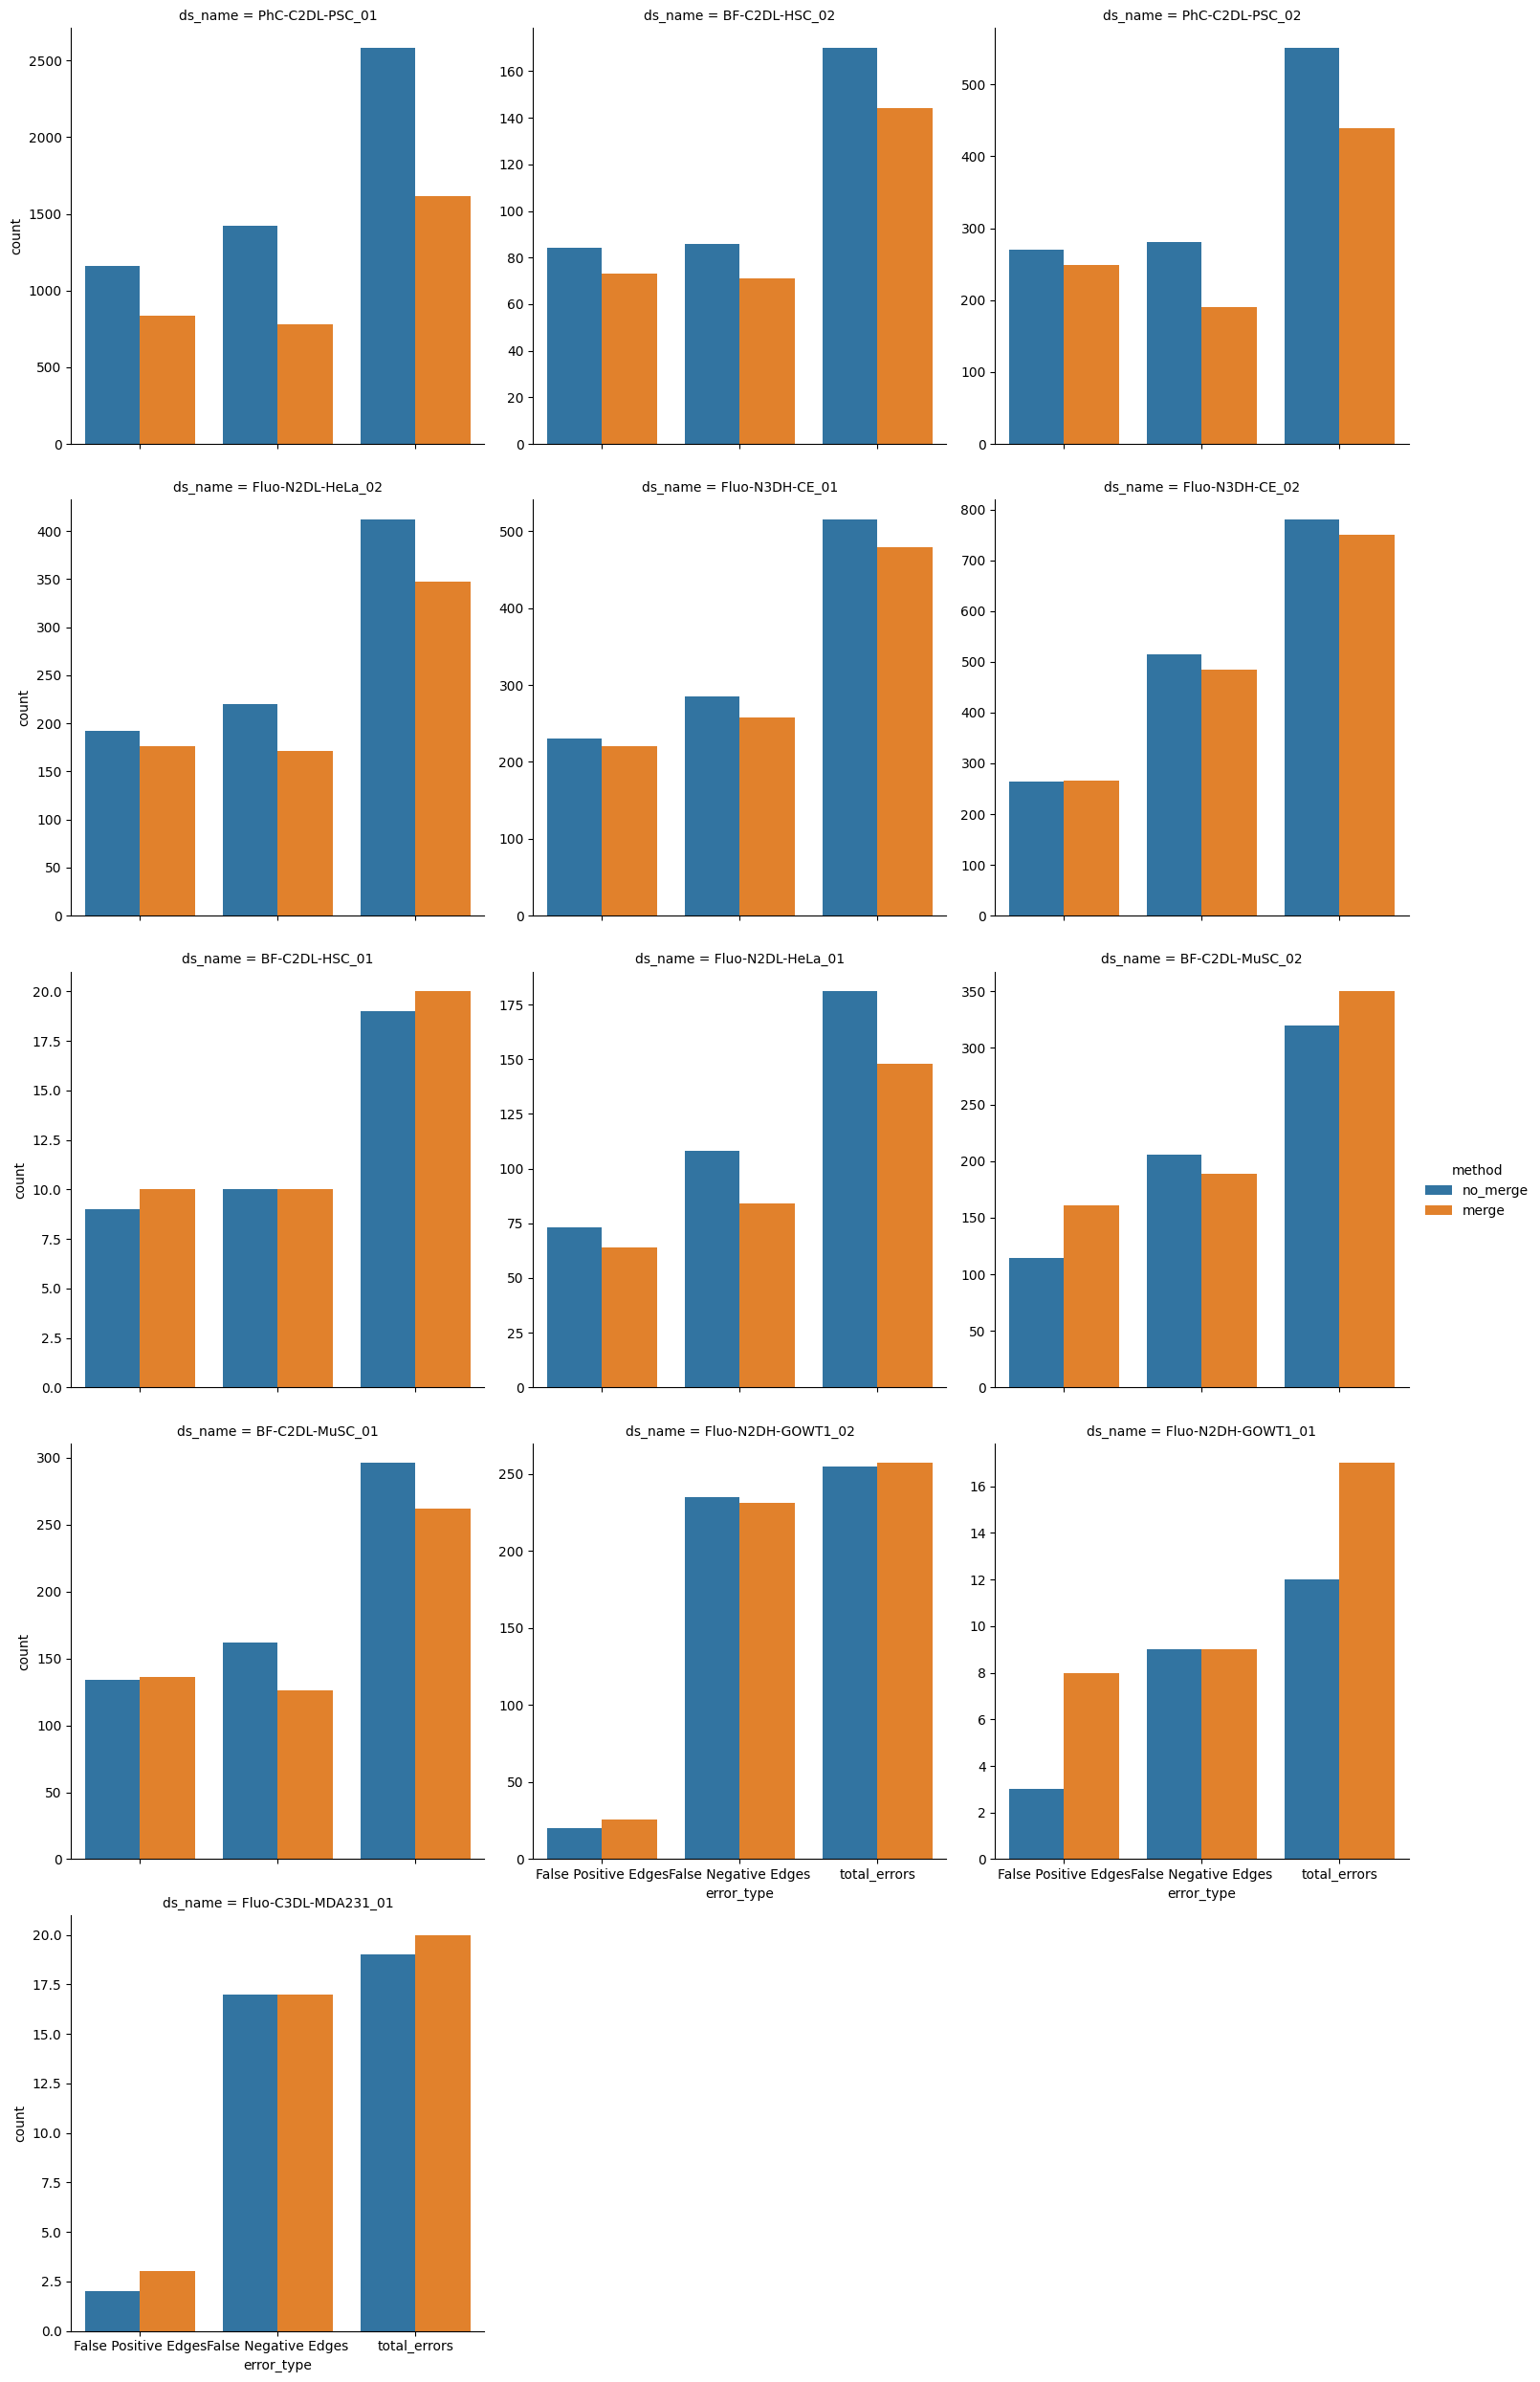

In [15]:
import pandas as pd                                                                                                                                                                                                   
import seaborn as sns                                                                                                                                                                                                 
import matplotlib.pyplot as plt                                                                                                                                                                                       

err_cols +=  ['total_errors']                                                                                                                                  

df_long = pd.melt(                                                                                                                                                                                                    
    merged,                                                                                                                                                                                                           
    id_vars=['ds_name'],                                                                                                                                                                                              
    value_vars=err_cols + [f'{c}_merge' for c in err_cols],                                                                                                                                                      
    var_name='error_type',                                                                                                                                                                                            
    value_name='count'                                                                                                                                                                                                
)                                                                                                                                                                                                                     
                                                                                                                                                                                                                    
# Add a 'method' column                                                                                                                                                                                               
df_long['method'] = df_long['error_type'].apply(lambda x: 'merge' if '_merge' in x else 'no_merge')                                                                                                                  
df_long['error_type'] = df_long['error_type'].str.replace('_merge', '')                                                                                                                                              

# Plot                                                                                                                                                                                                                
g = sns.catplot(                                                                                                                                                                                                      
    data=df_long,                                                                                                                                                                                                     
    x='error_type',                                                                                                                                                                                                   
    y='count',                                                                                                                                                                                                        
    hue='method',                                                                                                                                                                                                     
    col='ds_name',                                                                                                                                                                                                    
    kind='bar',                                                                                                                                                                                                       
    col_wrap=3,  # adjust based on number of datasets,
    col_order=[ds_name for ds_name in col_order if ds_name in ds_names_w_resolved_merges],
    sharey=False,
    legend_out=True                                                                                                                                                            
)
# g.add_legend(loc='lower right')

In [10]:
method_metrics['post_merges'][['ds_name', 'fp_edges', 'fn_edges', 'ws_edges']]

,ds_name,fp_edges,fn_edges,ws_edges
0,PhC-C2DL-PSC_02,217,153,197
1,BF-C2DL-MuSC_02,66,82,12
2,BF-C2DL-HSC_01,8,8,2
3,Fluo-N3DH-CE_01,199,233,334
4,BF-C2DL-HSC_02,70,68,70
5,Fluo-N2DH-GOWT1_02,22,219,17
6,Fluo-N2DL-HeLa_02,154,130,164
7,Fluo-N3DH-CE_02,219,410,393
8,PhC-C2DL-PSC_01,395,273,356
9,BF-C2DL-MuSC_01,116,101,55


In [13]:
method_metrics['post_no_merges'][['ds_name', 'fp_edges', 'fn_edges', 'ws_edges']]

,ds_name,fp_edges,fn_edges,ws_edges
0,PhC-C2DL-PSC_02,242,228,190
1,BF-C2DL-MuSC_02,67,86,9
2,BF-C2DL-HSC_01,8,8,2
3,Fluo-N3DH-CE_01,204,243,347
4,BF-C2DL-HSC_02,61,61,57
5,Fluo-N2DH-GOWT1_02,18,221,11
6,Fluo-N2DL-HeLa_02,174,169,135
7,Fluo-N3DH-CE_02,227,423,401
8,PhC-C2DL-PSC_01,471,425,336
9,BF-C2DL-MuSC_01,118,130,27


In [11]:
395+273

668

In [12]:
834+ 781

1615